In [6]:
import json
import os
import json
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
model_name_mapping = {
    "LIBERO_REALTIME": "triton",
    "LIBERO_PI0": "jax.jit",
    "LIBERO_PYTORCH": "torch.compile"
}
def load_benchmark_results(gpu: str):
    # Dictionary to store all benchmark results
    all_results = []

    for model in ["LIBERO_REALTIME", "LIBERO_PI0", "LIBERO_PYTORCH"]:
        benchmark_results_dir = f"/nethome/dhe83/flash/openpi/benchmarks/{gpu}_{model}"
        
        # Load all benchmark files
        for filename in os.listdir(benchmark_results_dir):
            if filename.endswith('.json'):
                filepath = os.path.join(benchmark_results_dir, filename)
                
                with open(filepath, 'r') as f:
                    data = json.load(f)
                
                # Extract summary statistics and metadata
                result = {
                    'model': model_name_mapping[model],
                    'filename': filename,
                    'date': data['date'],
                    'env': data['env'],
                    'num_steps': data['num_steps'],
                    'action_horizon': data['action_horizon'],
                    'batch_size': data['batch_size'],
                    'num_requests': data['num_requests'],
                    'request_rate': data['request_rate'],
                    'max_concurrency': data['max_concurrency'],
                    'duration': data['duration'],
                    'completed': data['completed'],
                    'failed': data['failed'],
                    'request_throughput': data['request_throughput'],
                    'mean_latency_ms': data['mean_latency_ms'],
                    'median_latency_ms': data['median_latency_ms'],
                    'std_latency_ms': data['std_latency_ms'],
                    'p95_latency_ms': data['p95_latency_ms'],
                    'p99_latency_ms': data['p99_latency_ms'],
                    'gpu_name': data.get('gpu_info', {}).get('gpu_name', 'Unknown'),
                }
                
                all_results.append(result)

    # Create DataFrame with summary statistics
    df_summary = pd.DataFrame(all_results)
    df_summary['date'] = pd.to_datetime(df_summary['date'])
    df_summary = df_summary.sort_values(['model', 'date'])

    print(f"Loaded {len(df_summary)} benchmark runs")
    print(f"\nModels: {df_summary['model'].unique()}")
    print(f"\nSummary DataFrame shape: {df_summary.shape}")
    # print(df_summary.head())
    return df_summary

In [22]:
l40s = load_benchmark_results('l40s')
# a40 = load_benchmark_results('a40')

Loaded 67 benchmark runs

Models: ['jax.jit' 'torch.compile' 'triton']

Summary DataFrame shape: (67, 20)


In [23]:
def plot_metric(df_summary, metric):

    # Choose your metric
    metric = 'request_throughput'  # You can change this to any column
    metric_max = df_summary[metric].max()

    # Get unique request rates
    # request_rates = sorted(df_summary['request_rate'].unique())
    request_rates = [100]
    
    # Create a subplot for each request_rate
    n_rates = len(request_rates)
    fig, axes = plt.subplots(1, n_rates, figsize=(6*n_rates, 5), squeeze=False)
    axes = axes.flatten()

    for idx, rate in enumerate(request_rates):
        ax = axes[idx]
        
        # Filter data for this request rate
        df_rate = df_summary[df_summary['request_rate'] == rate]
        
        # Pivot for easier plotting: rows=batch_size, cols=model
        pivot_data = df_rate.pivot_table(
            values=metric, 
            index='batch_size', 
            columns='model', 
            aggfunc='mean'  # In case there are multiple runs
        )
        
        # Create grouped bar chart
        pivot_data.plot(kind='bar', ax=ax, rot=0)
        
        ax.set_title(f'Request Rate: {rate} req/s', fontsize=12, fontweight='bold')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.legend(title='Model')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, metric_max * 1.5)

    plt.tight_layout()
    plt.show()

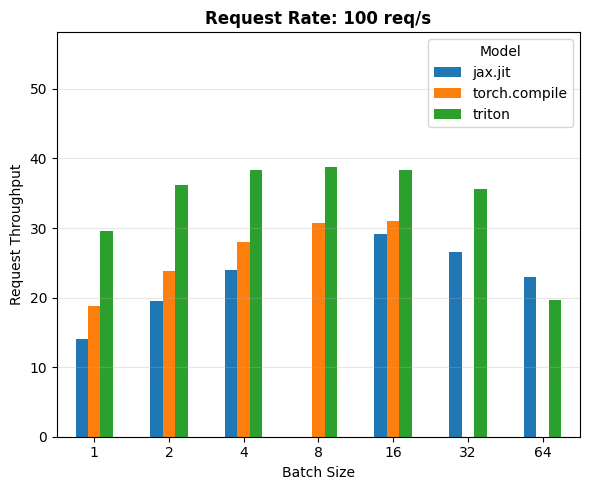

In [24]:
plot_metric(l40s, 'request_throughput')

In [11]:
l40s[(l40s['model'] == 'LIBERO_REALTIME') & (l40s['request_rate'] == 100)].sort_values('batch_size')

,model,filename,date,env,num_steps,action_horizon,batch_size,num_requests,request_rate,max_concurrency,duration,completed,failed,request_throughput,mean_latency_ms,median_latency_ms,std_latency_ms,p95_latency_ms,p99_latency_ms,gpu_name
23,LIBERO_REALTIME,benchmark-libero-20260113-170616.json,2026-01-13 17:06:16.174877+00:00,libero,10,50,1,300,100.0,300,10.151742,300,0,29.551578,3624.929645,3661.162306,2029.674853,6684.218265,6981.856781,NVIDIA L40S
20,LIBERO_REALTIME,benchmark-libero-20260113-170612.json,2026-01-13 17:06:12.106190+00:00,libero,10,50,2,300,100.0,300,8.289448,300,0,36.190588,2703.509319,2738.836613,1476.584287,4893.707089,5136.221133,NVIDIA L40S
14,LIBERO_REALTIME,benchmark-libero-20260113-170834.json,2026-01-13 17:08:34.258451+00:00,libero,10,50,4,300,100.0,300,7.833029,300,0,38.299361,2500.778213,2534.851810,1321.570505,4460.578732,4657.727810,NVIDIA L40S
24,LIBERO_REALTIME,benchmark-libero-20260113-170831.json,2026-01-13 17:08:31.918824+00:00,libero,10,50,8,300,100.0,300,7.740248,300,0,38.758450,2527.948758,2562.663018,1260.326469,4402.163097,4569.036644,NVIDIA L40S
18,LIBERO_REALTIME,benchmark-libero-20260113-170839.json,2026-01-13 17:08:39.287542+00:00,libero,10,50,16,300,100.0,300,7.838077,300,0,38.274694,2733.013911,2765.922677,1222.184766,4500.531629,4769.416067,NVIDIA L40S
6,LIBERO_REALTIME,benchmark-libero-20260113-170849.json,2026-01-13 17:08:49.104719+00:00,libero,10,50,32,300,100.0,300,8.413010,300,0,35.659056,3224.855511,3280.507684,1193.828235,4896.097183,5372.466997,NVIDIA L40S
16,LIBERO_REALTIME,benchmark-libero-20260113-170923.json,2026-01-13 17:09:23.091489+00:00,libero,10,50,64,300,100.0,300,15.240099,300,0,19.684911,8268.670949,8478.972331,2597.100875,12336.518608,12465.520742,NVIDIA L40S
